# Notebook 00 - Project Setup & Dataset Sanity Check

This notebook performs the initial verification of the dataset and project structure before any data processing begins.

The goal is to confirm that the dataset exists in the expected location (`data/prepared/`) and that the class folders (`cats`, `dogs`, `wildlife`) are present and populated with images. It also performs a quick sanity check by loading a small random sample of images and displaying them to ensure the files are readable and correctly formatted.

Additionally, this notebook prepares the project environment by ensuring that the reporting directories (`reports/figures` and `reports/metrics`) exist. These directories will later store dataset statistics and visualization outputs.

Running this notebook confirms that the dataset is accessible, structurally correct, and ready for the next stage of the pipeline.

In [10]:
from pathlib import Path
import random
import os

PROJECT_ROOT = Path.cwd().parent
DATA_PREPARED_DIR = PROJECT_ROOT / "data" / "prepared"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PREPARED_DIR:", DATA_PREPARED_DIR)

PROJECT_ROOT: f:\Projects\AnimalClassification
DATA_PREPARED_DIR: f:\Projects\AnimalClassification\data\prepared


In [4]:
CLASSES = ["cats", "dogs", "wildlife"]

missing = [c for c in CLASSES if not (DATA_PREPARED_DIR / c).exists()]
if missing:
    raise FileNotFoundError(f"Missing class folders in data/prepared: {missing}")

print("Found class folders:", CLASSES)

Found class folders: ['cats', 'dogs', 'wildlife']


In [5]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(folder: Path):
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

counts = {}
all_images = []

for c in CLASSES:
    imgs = list_images(DATA_PREPARED_DIR / c)
    counts[c] = len(imgs)
    all_images.extend([(p, c) for p in imgs])

total = sum(counts.values())
print("Counts per class:", counts)
print("Total images:", total)

Counts per class: {'cats': 23693, 'dogs': 22894, 'wildlife': 16072}
Total images: 62659


In [6]:
from PIL import Image

sample = random.sample(all_images, k=min(30, len(all_images)))

loaded = 0
failed = []

for path, label in sample:
    try:
        with Image.open(path) as im:
            im.verify()
        loaded += 1
    except Exception as e:
        failed.append((str(path), label, str(e)))

print("Sample loaded:", loaded)
print("Sample failed:", len(failed))
if failed:
    failed[:5]

Sample loaded: 30
Sample failed: 0


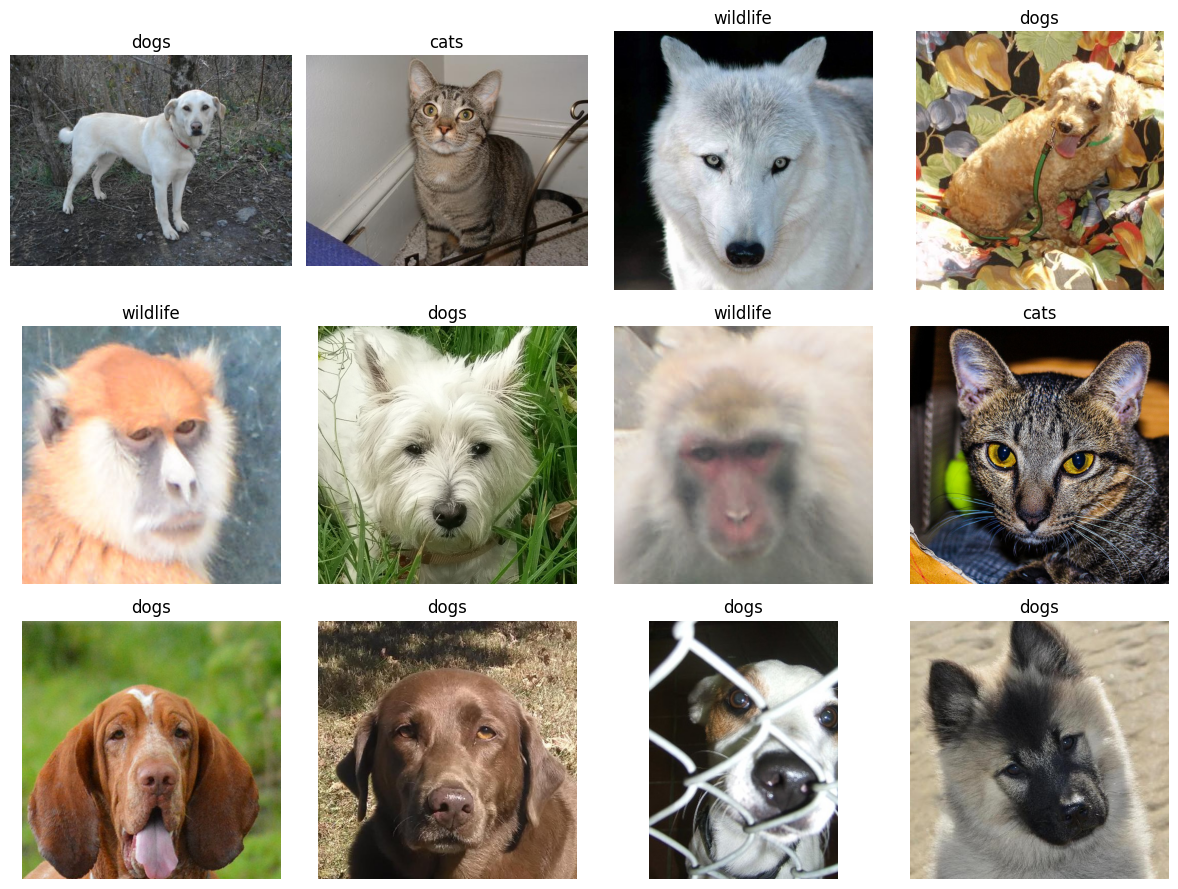

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

n = 12
sample = random.sample(all_images, k=min(n, len(all_images)))

cols = 4
rows = (len(sample) + cols - 1) // cols

plt.figure(figsize=(12, 3 * rows))
for i, (path, label) in enumerate(sample, 1):
    img = Image.open(path).convert("RGB")
    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()